# Phase 4.4: XGBoost

**Tujuan:** Klasifikasi emosi menggunakan XGBoost (gradient boosting) pada fitur GC,
band PDC terbaik, dan Combined, serta analisis feature importance berbasis gain.

**Validasi:** Stratified 5-Fold Cross-Validation (skor per-fold disimpan untuk uji
signifikansi lintas-fitur di 4.7).
**Output:** `output/xgboost_cv_scores.csv`, `output/xgboost_results.csv`, `output/xgboost_feature_importance.csv`
**Figures:** `figures/xgboost_feature_importance.png`

> Jika XGBoost tidak terinstall, notebook ini akan berhenti dengan pesan yang jelas
> tanpa membuat file output/figure kosong.


In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedGroupKFold, cross_validate
from sklearn.feature_selection import f_classif, SelectKBest
import warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, r"D:\Skripsi\new_data")

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
    print("XGBoost is installed and ready")
except ImportError:
    HAS_XGB = False
    print("XGBoost not installed - skipping this sub-phase")

PHASE3_CSV_DIR = r"D:\Skripsi\new_data\phase_3_feature_engineering\csv"
OUTPUT_DIR = r"D:\Skripsi\new_data\phase_4_classification\4.4_xgboost\output"
FIG_DIR = r"D:\Skripsi\new_data\phase_4_classification\4.4_xgboost\figures"
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)


XGBoost is installed and ready


In [2]:
assert HAS_XGB, 'XGBoost is required for this notebook. Install with: pip install xgboost'

def _feature_cols(df):
    exclude = ['subject_id', 'subject_num', 'session', 'trial', 'class', 'class_label']
    exclude += [c for c in df.columns if 'hub_channel' in c]
    cols = [c for c in df.columns if c not in exclude and df[c].dtype in ['float64', 'int64']]
    return [c for c in cols if df[c].std() > 1e-10]

df_gc = pd.read_csv(os.path.join(PHASE3_CSV_DIR, "engineered_features_gc.csv"))
df_combined = pd.read_csv(os.path.join(PHASE3_CSV_DIR, "engineered_features_combined.csv"))
df_spectral = pd.read_csv(os.path.join(PHASE3_CSV_DIR, "engineered_features_spectral.csv"))

pdc_files = [f for f in os.listdir(PHASE3_CSV_DIR)
             if f.startswith("engineered_features_pdc_") and "broadband" not in f]

best_pdc, best_pdc_name, best_score = None, None, -1
print("Selecting best PDC band by mean ANOVA F-score:")
for f in pdc_files:
    df_pdc = pd.read_csv(os.path.join(PHASE3_CSV_DIR, f))
    band = f.replace("engineered_features_pdc_", "").replace(".csv", "")
    feat_cols = _feature_cols(df_pdc)
    f_scores, _ = f_classif(df_pdc[feat_cols].fillna(0).values, df_pdc['class'].values)
    score = np.nanmean(f_scores)
    print(f"  PDC {band.upper():5s}: mean F-score = {score:.4f} ({len(feat_cols)} features)")
    if score > best_score:
        best_score, best_pdc, best_pdc_name = score, df_pdc, f"PDC_{band.title()}"

print(f"\nGC shape       : {df_gc.shape}")
print(f"Best PDC band  : {best_pdc_name} (shape: {best_pdc.shape})")
print(f"Combined shape : {df_combined.shape}")
print(f"Spectral shape : {df_spectral.shape}")
ROI_DIR = r"D:\Skripsi\new_data\phase_3_feature_engineering\3.4_roi_aggregation\output"
df_gc_roi = pd.read_csv(os.path.join(ROI_DIR, "engineered_features_gc_roi.csv"))
df_pdc_roi = pd.read_csv(os.path.join(ROI_DIR, "engineered_features_pdc_roi_combined.csv"))
df_gc_pdc_roi = pd.read_csv(os.path.join(ROI_DIR, "engineered_features_roi_gc_pdc.csv"))
df_gc_pdc_roi_spectral = pd.read_csv(os.path.join(ROI_DIR, "engineered_features_roi_all.csv"))
print(f"GC_ROI shape             : {df_gc_roi.shape}")
print(f"PDC_ROI shape            : {df_pdc_roi.shape}")
print(f"GC+PDC_ROI shape         : {df_gc_pdc_roi.shape}")
print(f"GC+PDC_ROI+Spectral shape: {df_gc_pdc_roi_spectral.shape}")

Selecting best PDC band by mean ANOVA F-score:
  PDC ALPHA: mean F-score = 3.3176 (282 features)


  PDC BETA : mean F-score = 3.0740 (282 features)
  PDC DELTA: mean F-score = 3.2196 (282 features)


  PDC GAMMA: mean F-score = 2.9619 (282 features)
  PDC THETA: mean F-score = 3.4114 (282 features)

GC shape       : (675, 296)
Best PDC band  : PDC_Theta (shape: (675, 296))
Combined shape : (675, 2676)
Spectral shape : (675, 646)


GC_ROI shape             : (675, 56)
PDC_ROI shape            : (675, 306)
GC+PDC_ROI shape         : (675, 356)
GC+PDC_ROI+Spectral shape: (675, 996)


In [3]:
def prepare_features(df):
    exclude = ['subject_id', 'subject_num', 'session', 'trial', 'class', 'class_label']
    exclude += [c for c in df.columns if 'hub_channel' in c]
    feature_cols = [c for c in df.columns if c not in exclude and df[c].dtype in ['float64', 'int64']]
    feature_cols = [c for c in feature_cols if df[c].std() > 1e-10]
    # Subject-wise z-score: samakan baseline & skala tiap subjek sebelum digabung
    # lintas subjek. Tidak bocor lintas fold: hanya pakai statistik (mean/std)
    # milik subjek itu sendiri, dan grouped CV selalu menaruh semua trial 1
    # subjek di 1 sisi (train atau test), jadi transform ini independen dari fold.
    df_norm = df.copy()
    grp = df_norm.groupby('subject_id')[feature_cols]
    mean = grp.transform('mean')
    std = grp.transform('std').replace(0, np.nan)
    df_norm[feature_cols] = (df_norm[feature_cols] - mean) / std
    X = df_norm[feature_cols].fillna(0).values
    y = df['class'].values
    # NOTE: groups=subject_id agar CV tidak membocorkan trial subjek yang sama ke
    # fold train & test sekaligus (StratifiedKFold biasa bisa mencampurnya karena
    # data 675 baris = 15 subjek x 45 trial, EEG sangat subject-specific).
    groups = df['subject_id'].values
    return X, y, groups, feature_cols

# Gabungkan Spectral dengan GC / PDC (fitur diprefix supaya tidak bentrok nama
# kolom antar sumber, mis. 'mean_out_degree' muncul identik di GC dan tiap band PDC).
KEY_COLS = ['subject_id', 'subject_num', 'session', 'trial', 'class', 'class_label']

def _prefix(df, prefix):
    return df.rename(columns={c: f"{prefix}_{c}" for c in df.columns if c not in KEY_COLS})

_gc_p = _prefix(df_gc, 'gc')
_pdc_p = _prefix(best_pdc, 'pdc')
_spec_p = _prefix(df_spectral, 'spec')

df_gc_spectral = _gc_p.merge(_spec_p, on=KEY_COLS)
df_pdc_spectral = _pdc_p.merge(_spec_p, on=KEY_COLS)
df_gc_pdc_spectral = _gc_p.merge(_pdc_p, on=KEY_COLS).merge(_spec_p, on=KEY_COLS)

datasets = {}
for name, df in [
    ('GC', df_gc), (best_pdc_name, best_pdc), ('Combined', df_combined),
    ('Spectral', df_spectral),
    ('GC+Spectral', df_gc_spectral),
    (f'{best_pdc_name}+Spectral', df_pdc_spectral),
    (f'GC+{best_pdc_name}+Spectral', df_gc_pdc_spectral),
    ('GC_ROI', df_gc_roi),
    ('PDC_ROI', df_pdc_roi),
    ('GC+PDC_ROI', df_gc_pdc_roi),
    ('GC+PDC_ROI+Spectral', df_gc_pdc_roi_spectral),
]:
    X, y, groups, features = prepare_features(df)
    datasets[name] = {'X': X, 'y': y, 'groups': groups, 'features': features}
    print(f"{name:24s}: X={X.shape}")

GC                      : X=(675, 282)
PDC_Theta               : X=(675, 282)


Combined                : X=(675, 2614)


Spectral                : X=(675, 640)


GC+Spectral             : X=(675, 922)


PDC_Theta+Spectral      : X=(675, 922)


GC+PDC_Theta+Spectral   : X=(675, 1204)
GC_ROI                  : X=(675, 50)


PDC_ROI                 : X=(675, 300)
GC+PDC_ROI              : X=(675, 350)


GC+PDC_ROI+Spectral     : X=(675, 990)


In [4]:
cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
fold_rows, summary_rows = [], []

# FIX (dimensionality/speed): sama seperti 4.3 -- Combined ~28.500 kolom mentah,
# tambahkan SelectKBest supaya anggaran fitur setara dengan SVM/LDA (k<=1200) dan
# training tidak sangat lambat.
print("Running 5-fold CV for XGBoost:")
for name, d in datasets.items():
    X, y, groups = d['X'], d['y'], d['groups']
    k = min(1200, X.shape[1])
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('select', SelectKBest(f_classif, k=k)),
        ('clf', XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.05,
                               random_state=42, eval_metric='mlogloss', n_jobs=-1))
    ])
    scores = cross_validate(pipe, X, y, groups=groups, cv=cv, scoring=['accuracy', 'f1_weighted'])
    for fold_idx, (acc, f1) in enumerate(zip(scores['test_accuracy'], scores['test_f1_weighted'])):
        fold_rows.append({'Dataset': name, 'Model': 'XGBoost', 'Fold': fold_idx, 'Accuracy': acc, 'F1_weighted': f1})
    summary_rows.append({
        'Dataset': name, 'Model': 'XGBoost',
        'Mean_Accuracy': scores['test_accuracy'].mean(), 'Std_Accuracy': scores['test_accuracy'].std(),
        'Mean_F1': scores['test_f1_weighted'].mean(), 'Std_F1': scores['test_f1_weighted'].std(),
    })
    print(f"  {name:12s}: Acc={scores['test_accuracy'].mean():.3f}+/-{scores['test_accuracy'].std():.3f}  F1={scores['test_f1_weighted'].mean():.3f}")

df_fold = pd.DataFrame(fold_rows)
df_summary = pd.DataFrame(summary_rows).sort_values('Mean_Accuracy', ascending=False)
df_fold.to_csv(os.path.join(OUTPUT_DIR, 'xgboost_cv_scores.csv'), index=False)
df_summary.to_csv(os.path.join(OUTPUT_DIR, 'xgboost_results.csv'), index=False)
print()
print(df_summary.to_string(index=False))


Running 5-fold CV for XGBoost:


  GC          : Acc=0.545+/-0.061  F1=0.542


  PDC_Theta   : Acc=0.594+/-0.048  F1=0.592


  Combined    : Acc=0.735+/-0.035  F1=0.733


  Spectral    : Acc=0.711+/-0.044  F1=0.708


...

  GC+PDC_Theta+Spectral: Acc=0.726+/-0.036  F1=0.724


  GC_ROI      : Acc=0.588+/-0.057  F1=0.588


  PDC_ROI     : Acc=0.573+/-0.028  F1=0.572


  GC+PDC_ROI  : Acc=0.652+/-0.056  F1=0.653


  GC+PDC_ROI+Spectral: Acc=0.732+/-0.035  F1=0.731

              Dataset   Model  Mean_Accuracy  Std_Accuracy  Mean_F1   Std_F1
             Combined XGBoost       0.734815      0.034554 0.733380 0.035076
  GC+PDC_ROI+Spectral XGBoost       0.731852      0.035494 0.730951 0.037251
          GC+Spectral XGBoost       0.728889      0.036769 0.727578 0.036758
GC+PDC_Theta+Spectral XGBoost       0.725926      0.035679 0.723557 0.034747
             Spectral XGBoost       0.711111      0.043697 0.707826 0.044519
   PDC_Theta+Spectral XGBoost       0.708148      0.031287 0.704872 0.030737
           GC+PDC_ROI XGBoost       0.651852      0.056413 0.653415 0.055001
            PDC_Theta XGBoost       0.594074      0.048324 0.591763 0.047809
               GC_ROI XGBoost       0.588148      0.057301 0.587926 0.057753
              PDC_ROI XGBoost       0.573333      0.028342 0.571996 0.028653
                   GC XGBoost       0.545185      0.061191 0.541839 0.058558


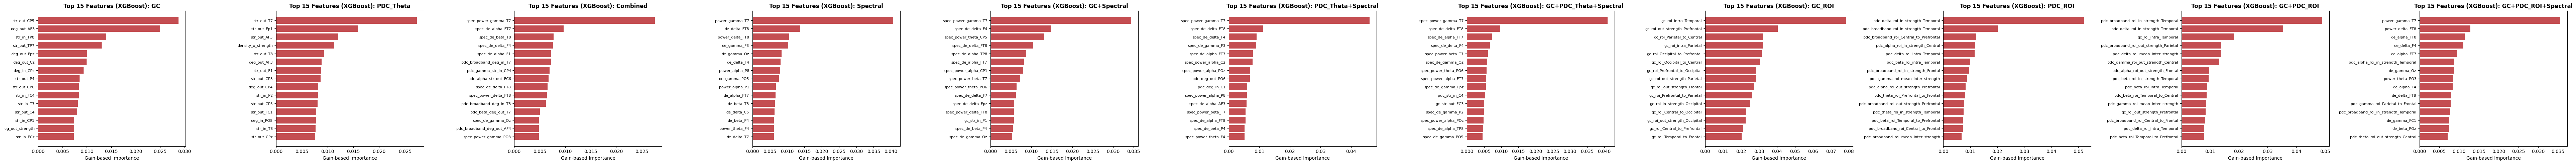

Saved xgboost_feature_importance.png and xgboost_feature_importance.csv


In [5]:
fig, axes = plt.subplots(1, len(datasets), figsize=(7*len(datasets), 5))
if len(datasets) == 1:
    axes = [axes]

importance_rows = []
for ax, (name, d) in zip(axes, datasets.items()):
    X, y, features = d['X'], d['y'], d['features']
    Xs = StandardScaler().fit_transform(X)
    k = min(1200, Xs.shape[1])
    selector = SelectKBest(f_classif, k=k)
    Xs_sel = selector.fit_transform(Xs, y)
    sel_features = [feat for feat, keep in zip(features, selector.get_support()) if keep]
    xgb = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.05,
                         random_state=42, eval_metric='mlogloss', n_jobs=-1)
    xgb.fit(Xs_sel, y)
    importance = xgb.feature_importances_
    order = np.argsort(importance)[::-1][:15]
    top_feats = [sel_features[i] for i in order]
    top_vals = importance[order]
    ax.barh(range(len(top_feats)), top_vals[::-1], color='#c44e52')
    ax.set_yticks(range(len(top_feats)))
    ax.set_yticklabels(top_feats[::-1], fontsize=8)
    ax.set_xlabel('Gain-based Importance')
    ax.set_title(f'Top 15 Features (XGBoost): {name}', fontweight='bold')
    for feat, val in zip(top_feats, top_vals):
        importance_rows.append({'Dataset': name, 'Feature': feat, 'Gain_Importance': float(val)})

plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'xgboost_feature_importance.png'), dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

pd.DataFrame(importance_rows).to_csv(os.path.join(OUTPUT_DIR, 'xgboost_feature_importance.csv'), index=False)
print("Saved xgboost_feature_importance.png and xgboost_feature_importance.csv")


In [6]:
print("="*70)
print("4.4 XGBOOST COMPLETE")
print("="*70)
best = df_summary.iloc[0]
print(f"Best: {best['Dataset']} -> Acc={best['Mean_Accuracy']:.4f}+/-{best['Std_Accuracy']:.4f}, F1={best['Mean_F1']:.4f}")
print(f"Outputs saved in: {OUTPUT_DIR}")
print(f"Figures saved in: {FIG_DIR}")


4.4 XGBOOST COMPLETE
Best: Combined -> Acc=0.7348+/-0.0346, F1=0.7334
Outputs saved in: D:\Skripsi\new_data\phase_4_classification\4.4_xgboost\output
Figures saved in: D:\Skripsi\new_data\phase_4_classification\4.4_xgboost\figures
